# 07: build the clustering from scratch, then find the pregnancy changes

### CAJAL NEUROMICS summer school, Bordeaux 2026 · a spatial metabolomics primer

*Luca Fusar Bassini · hands-on notebook 7 of 9 · ~90 minutes*

---

Until now somebody handed you the lipizones. Pixels arrived pre-coloured by territory, and you
trusted the colours. Today we earn them. We build a clustering algorithm with our own hands, one
recursive split at a time, and we discover the single rule that turns a clustering into *biology*: a
split is only allowed to exist if the two halves it creates differ in real, measurable lipids.

That rule is a statistical test, the Mann-Whitney rank-sum test with a Benjamini-Hochberg correction.
We will build that test from the ground up too, because it is the same machine we then point at the
real question of this course: what does pregnancy do to the lipids of the brain? The two halves of the
notebook are the same idea used twice. First we split a healthy brain into territories and demand that
each split be backed by differential lipids. Then we hold the territory fixed and ask whether control
and pregnant pixels inside it differ. Same test, two jobs.

Here is the road:

> **a divisive splitter from scratch (re-embed, cut in two, gate on differential lipids) → the Mann-Whitney + Benjamini-Hochberg test, unrolled → control vs pregnant, overall and per Allen region → the volcano → marker lipids and the sorted heatmaps that read out what each territory is made of → composite scores (membrane remodeling, myelination) painted back onto the tissue**

Every number you see below comes from code that ran on the two real sections, `217D` (control) and
`Brain1_C2` (pregnant), the same coronal plane at about AP 6.5. Nothing is invented.

## the callouts

The four markers from the earlier notebooks run through this one too:

- 🔬 **TASK** something you do (write or run code).
- 💡 **HINT** a nudge when you are stuck.
- ❓ **QUESTION** pause and think; no code required.
- ⚠️ **CHECKPOINT** what you should see if it worked. If your screen disagrees, stop and fix it before moving on.

🔬 **TASK.** Run the next cell to load the stack. Everything here you met in the earlier notebooks,
plus the course helper package `cajal_lipidomics`, which holds the tested, beautiful versions of the
recipes we are about to unroll by hand.

In [1]:
# the scientific-Python stack
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad

# the small NMF fits below are deliberately short; silence the "max_iter reached" notices
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# the pieces of scikit-learn / scipy / statsmodels we build our splitter and test from
from sklearn.decomposition import NMF
from sklearn.cluster import KMeans
from scipy.stats import mannwhitneyu, rankdata
from statsmodels.stats.multitest import multipletests

# the course helper package: the tested versions of the recipes we unroll
import cajal_lipidomics as cl
from cajal_lipidomics import analysis, embedding, plotting
from cajal_lipidomics.style import set_style, FS
set_style()  # the lab figure style: clean, vector text, no top/right spines

# one global seed so every number and figure below is reproducible
SEED = 0
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

print("ready. numpy", np.__version__, "| pandas", pd.__version__)

ready. numpy 2.2.6 | pandas 2.3.3


⚠️ **CHECKPOINT.** You should see `ready. numpy ... | pandas ...` and no red error. A
`ModuleNotFoundError` means the wrong kernel is selected; pick `cajal-lipidomics` from the kernel
picker (top right) and run the cell again.

## load the two sections

Our substrate is one file, `data/sections_pair.h5ad`, an AnnData object. Think of an AnnData as a
spreadsheet with three coordinated parts:

- `adata.X` is the data matrix, **174768 pixels (rows) by 173 lipids (columns)**. Every entry is a
  uMAIA-normalized lipid intensity. A pixel is one MALDI laser spot on the tissue, not one cell; it
  mixes cell bodies, axons, dendrites, and glial projections under a single ~5 µm spot.
- `adata.var_names` is the list of 173 lipid names, the column labels.
- `adata.obs` is the per-pixel metadata table: which `Condition` (naive control or pregnant), which
  `SectionID`, the Allen Common Coordinate Framework position (`zccf`, `yccf`, `xccf`), the Allen
  region `acronym`, and the pre-computed `lipizone_names` we will pretend not to have for the first
  half of the notebook.

🔬 **TASK.** Load the file and look at its shape.

In [2]:
adata = ad.read_h5ad("/home/fusar/lipidomics_tutorial_cajalcourse/data/sections_pair.h5ad")
print("pixels x lipids:", adata.shape)
print("conditions:", dict(adata.obs["Condition"].value_counts()))
print("first 8 lipids:", list(adata.var_names[:8]))

pixels x lipids: (174768, 173)
conditions: {'pregnant': np.int64(90447), 'naive': np.int64(84321)}
first 8 lipids: ['HexCer 42:2;O2', 'HexCer 42:1;O2', 'HexCer 40:1;O2', 'PC 38:6', 'PA 34:1', 'SM 36:1;O2', 'HexCer 40:2;O2', 'PG 40:6']


⚠️ **CHECKPOINT.** The shape is `(174768, 173)`. The two conditions are `naive` (84321 pixels,
the control section `217D`) and `pregnant` (90447 pixels, the section `Brain1_C2`). The lipid names
read like `HexCer 42:2;O2` and `PC 38:6`: a class, then total acyl carbons, a colon, then the number
of double bonds. We decode that nomenclature properly below.

One sentence to keep in your pocket for the whole notebook. We learn the clustering on the **control**
brain only, because the territories of the healthy brain are what we want to define; then we ask what
pregnancy changes *inside* those territories. So we make a control-only view right away.

In [3]:
# control-only view: this is the brain we learn the territories from
control = adata[adata.obs["Condition"] == "naive"].copy()
print("control pixels:", control.n_obs)
print("control section:", control.obs["SectionID"].unique().tolist())

control pixels: 84321
control section: [75.0]


# Part 1: a divisive splitter, built one split at a time

The Lipid Brain Atlas does not discover its territories with one flat clustering. It uses a
**divisive, top-down, binary splitter**. Start with all the pixels of the control brain at the root.
Cut them into two groups. Then recurse: cut each group into two again, and again, building a binary
tree whose leaves are the finest territories, the lipizones. The path of left/right decisions down to
a leaf is that lipizone's barcode.

Two design choices make this work, and we will feel both by hand.

**First, re-embed at every node.** A single global decomposition of the whole brain is dominated by
its loudest contrast, grey matter versus white matter. Once you have conditioned on that, the *next*
most informative lipid directions are different and local. So at each node we run a fresh, small NMF
on just the pixels in that node. Coarse structure removed, fine structure surfaces.

**Second, and this is the heart of the lesson, gate every split on differential lipids.** A cut is
only kept if the two halves it makes are actually distinguishable by their lipids: at least two lipids
that pass a statistical test with a meaningful fold change. A cut that splits pixels into two groups
with the *same* lipid composition is not biology, it is noise, and we throw it away. This single gate
is why the tree means something. We build the gate first, then the splitter that calls it.

## the gate, step 1: ranks instead of values (Mann-Whitney)

We want to ask, for one lipid, whether its values differ between group A and group B. The famous
t-test compares the *means* and assumes each group is roughly bell-shaped. MALDI lipid intensities are
not bell-shaped; they are skewed, with long tails and the occasional huge pixel. So we use a test that
throws away the actual values and keeps only their **order**: the Mann-Whitney U test, also called the
Wilcoxon rank-sum test. They are the same test under two names.

The idea is almost childishly simple. Pool the values from both groups. Replace each value by its
**rank** (smallest = 1, largest = N). If the two groups are drawn from the same distribution, group A
should hold a random, middling share of the ranks. If group B is systematically higher, B grabs the
big ranks and its rank-sum is large. The test measures exactly that.

Let us see it on a toy first, two tiny groups, by hand.

🔬 **TASK.** Run the cell. Watch the values turn into ranks, then into a U statistic.

In [4]:
# a tiny toy: group B is shifted up relative to group A
A = np.array([1.0, 2.0, 3.0, 4.0])
B = np.array([3.5, 5.0, 6.0, 7.0])

# pool, then rank everything together (ties would get the average rank)
pooled = np.concatenate([A, B])
ranks = rankdata(pooled)               # smallest value -> rank 1
rank_A = ranks[: len(A)]               # the ranks that landed on group A
rank_B = ranks[len(A) :]               # the ranks that landed on group B

print("pooled values:", pooled)
print("their ranks:  ", ranks)
print("sum of ranks in A:", rank_A.sum(), " in B:", rank_B.sum())

# Mann-Whitney U from the rank sums (the textbook formula)
nA, nB = len(A), len(B)
U_A = rank_A.sum() - nA * (nA + 1) / 2   # how much A "beats" B across all pairs
U_B = nB * nA - U_A                      # the complementary count
print("U_A =", U_A, " U_B =", U_B, " (U = min =", min(U_A, U_B), ")")

pooled values: [1.  2.  3.  4.  3.5 5.  6.  7. ]
their ranks:   [1. 2. 3. 5. 4. 6. 7. 8.]
sum of ranks in A: 11.0  in B: 25.0
U_A = 1.0  U_B = 15.0  (U = min = 1.0 )


So `U_A` literally counts, over every one of the `nA * nB` pairs (one value from A, one from B),
how often the A value is larger. Here A almost never wins, so `U_A` is small and `U_B` is large. A
small U means the two groups barely overlap in rank, which is evidence they differ. `scipy` turns U
into a p-value by comparing it to the distribution of U you would get if the labels were shuffled at
random.

🔬 **TASK.** Confirm `scipy`'s `mannwhitneyu` reproduces our U, and read its p-value.

In [5]:
stat, p = mannwhitneyu(A, B, alternative="two-sided")
print("scipy U statistic:", stat, " (matches our min(U_A, U_B) =", min(U_A, U_B), ")")
print("scipy p-value:", round(p, 4))

scipy U statistic: 1.0  (matches our min(U_A, U_B) = 1.0 )
scipy p-value: 0.0571


❓ **QUESTION.** The p-value here is not tiny, because each group has only four points: even a
clean shift can happen by chance when N is small. In the brain we compare *thousands* of pixels per
group, so a real shift gives an astronomically small p. That sensitivity is also a trap, which is the
next idea: with 173 lipids tested at once, some will look significant by pure luck. We fix that with
Benjamini-Hochberg.

## the gate, step 2: fold change, the size of the difference

A p-value tells you the difference is *real* (unlikely to be chance). It does not tell you the
difference is *big*. With thousands of pixels, a microscopic, biologically meaningless shift can have
a p-value of essentially zero. So we pair every p-value with an **effect size**: the log2 fold change.

Take the mean of the lipid in group B, divide by its mean in group A, and take the base-2 logarithm:

> `log2FC = log2( mean_B / mean_A )`

A log2FC of `+1` means group B has twice as much (`2^1`). `-1` means half (`2^-1`). `0` means no
change. Base 2 is the convention because doublings and halvings become clean integers, and because the
plot is symmetric: up and down by the same factor sit the same distance from zero.

🔬 **TASK.** Compute the log2FC of our toy lipid by hand.

In [6]:
mean_A, mean_B = A.mean(), B.mean()
log2fc = np.log2(mean_B / mean_A)
print(f"mean_A = {mean_A:.2f}, mean_B = {mean_B:.2f}")
print(f"log2 fold change (B / A) = {log2fc:.2f}  ->  B is {2**log2fc:.1f}x group A")

mean_A = 2.50, mean_B = 5.38
log2 fold change (B / A) = 1.10  ->  B is 2.1x group A


The gate accepts a lipid as *differential* only when **both** are true: the p-value is small
**and** the absolute log2FC is large enough. The Lipid Brain Atlas uses `|log2FC| > 0.2` (about a 15%
change) and an adjusted p below `0.05`. Two thresholds, one for reality and one for magnitude. But
"adjusted p" needs the third idea.

## the gate, step 3: Benjamini-Hochberg, taming many tests at once

Here is the problem in one sentence. If you run 173 independent tests and call everything with `p <
0.05` a hit, then even when *nothing* is real you expect about `173 * 0.05 ≈ 9` false hits. Test enough
lipids and you will always find "significant" ones by chance. This is the multiple-comparisons problem,
and it is the single most common way to fool yourself in omics.

The Benjamini-Hochberg procedure controls the **false discovery rate**: among the lipids you *call*
significant, it caps the expected fraction that are false at your chosen level (say 5%). The recipe is
short enough to do by hand, and doing it once demystifies it forever.

1. Sort the p-values from smallest to largest: `p(1) ≤ p(2) ≤ ... ≤ p(m)`.
2. Give each a rank `i` (1 for the smallest).
3. Compare each `p(i)` to its own moving threshold `(i / m) * alpha`. The smallest p faces the
   strictest bar; the largest p faces the loosest.
4. Find the largest rank `k` whose `p(k) ≤ (k/m) * alpha`. Everything up to rank `k` is significant.
5. The *adjusted* p-value (the q-value) is, walking from the largest p down, the running minimum of
   `p(i) * m / i`. That is the number we threshold at `alpha` later.

🔬 **TASK.** Run our by-hand Benjamini-Hochberg on a small set of p-values and check it against
`statsmodels`.

In [7]:
# six pretend p-values from six tests
pvals = np.array([0.001, 0.008, 0.02, 0.04, 0.20, 0.70])
m = len(pvals)
alpha = 0.05

order = np.argsort(pvals)              # indices that sort p ascending
ranks = np.arange(1, m + 1)            # i = 1..m
sorted_p = pvals[order]

bh_threshold = ranks / m * alpha       # the moving bar (i/m)*alpha
passed = sorted_p <= bh_threshold
k = np.where(passed)[0].max() + 1 if passed.any() else 0   # largest passing rank

# the adjusted q-values: running minimum from the top of p * m / i
q_sorted = np.minimum.accumulate((sorted_p * m / ranks)[::-1])[::-1]
q = np.empty(m); q[order] = np.clip(q_sorted, 0, 1)

print("sorted p:      ", np.round(sorted_p, 4))
print("moving bar:    ", np.round(bh_threshold, 4))
print("largest passing rank k =", k, "-> the", k, "smallest p-values are significant")
print("our q-values:  ", np.round(q, 4))
print("statsmodels q: ", np.round(multipletests(pvals, alpha=alpha, method="fdr_bh")[1], 4))

sorted p:       [0.001 0.008 0.02  0.04  0.2   0.7  ]
moving bar:     [0.0083 0.0167 0.025  0.0333 0.0417 0.05  ]
largest passing rank k = 3 -> the 3 smallest p-values are significant
our q-values:   [0.006 0.024 0.04  0.06  0.24  0.7  ]
statsmodels q:  [0.006 0.024 0.04  0.06  0.24  0.7  ]


⚠️ **CHECKPOINT.** Our hand-rolled q-values match `statsmodels` exactly. Notice the effect: the
raw `p = 0.04` would pass a naive `0.05` cutoff, but after correction its q-value climbs above `0.05`
and it is no longer called significant. That is Benjamini-Hochberg doing its job, demanding more
evidence because we asked many questions.

❓ **QUESTION.** Why is the *largest* p compared to the *loosest* bar (`m/m * alpha = alpha`) and the
smallest p to the strictest (`1/m * alpha`)? Because if you are going to make many discoveries, the
later ones are allowed a higher chance of being false, as long as the *fraction* of false ones stays
controlled. It is a rate, not a count.

## the three steps, fused into one gate

Now we glue ranks, fold change, and Benjamini-Hochberg into one function: given two groups of pixels
and the lipid matrix, return for every lipid a log2FC, a raw p, a corrected q, and a significance flag.
The number we care about for the splitter is just the *count* of significant lipids.

🔬 **TASK.** Write the gate. Fill in the two blanks: the log2 fold change, and the Mann-Whitney call.

💡 **HINT.** `np.log2(mean_b / mean_a)` for the fold change; `mannwhitneyu(a[:, j], b[:, j],
alternative="two-sided")` returns `(stat, p)`, and you only need the `p`.

In [8]:
def differential_count(X, mask_a, mask_b, min_fc=0.2, qthr=0.05):
    '''How many lipids truly differ between two groups of pixels?

    For each lipid column j: log2 fold change of the means, Mann-Whitney p, then one
    Benjamini-Hochberg correction across all lipids. A lipid is differential if
    |log2FC| > min_fc AND corrected q < qthr. Returns (count, per-lipid table).
    '''
    a, b = X[mask_a], X[mask_b]
    pvals, fcs = [], []
    for j in range(X.shape[1]):
        mean_a = a[:, j].mean() + 1e-11      # +eps so we never divide by zero
        mean_b = b[:, j].mean() + 1e-11
        fcs.append(np.log2(mean_b / mean_a))                    # <-- BLANK 1: log2 fold change
        try:
            _, p = mannwhitneyu(a[:, j], b[:, j], alternative="two-sided")   # <-- BLANK 2
        except ValueError:                   # happens if a column is constant
            p = 1.0
        pvals.append(p)
    fcs = np.array(fcs)
    q = multipletests(pvals, alpha=qthr, method="fdr_bh")[1]    # BH across the lipids
    sig = (np.abs(fcs) > min_fc) & (q < qthr)
    return int(sig.sum()), pd.DataFrame({"log2fc": fcs, "q": q, "sig": sig})

Now the crucial demonstration, the one sentence the whole first half exists to teach. **A
random cut produces no differential lipids; a real biological cut produces many.** We split the
control pixels two ways: once at random (assign each pixel a coin flip) and once along the obvious
biology (the top NMF program, which captures the grey/white contrast). The gate should reject the
first and accept the second.

🔬 **TASK.** Run the comparison.

In [9]:
Xc = np.asarray(control.X, float)

# CUT 1: a coin flip per pixel -> no real structure
coin = rng.integers(0, 2, size=Xc.shape[0]).astype(bool)
n_random, _ = differential_count(Xc, coin, ~coin)

# CUT 2: along the loudest lipid axis. One quick NMF, split on the top program's median.
Xpos = Xc - Xc.min() + 1e-7
W = NMF(n_components=6, init="nndsvda", random_state=SEED, max_iter=200).fit_transform(Xpos)
top = W[:, 0]                                  # activity of the strongest lipid program
high = top > np.median(top)                    # half the pixels express it strongly
n_biology, _ = differential_count(Xc, high, ~high)

print(f"random coin-flip split:  {n_random:3d} differential lipids  -> gate REJECTS")
print(f"top-NMF-program split:   {n_biology:3d} differential lipids  -> gate ACCEPTS")

random coin-flip split:    0 differential lipids  -> gate REJECTS
top-NMF-program split:   138 differential lipids  -> gate ACCEPTS


⚠️ **CHECKPOINT.** The random split yields essentially **0** differential lipids, so the gate
rejects it. The biology-driven split yields *dozens*. This is the principle in numbers: a split earns
its place only when the two halves are lipidomically distinct. Carry this intuition into the recursion
below; it is the only thing standing between a meaningful tree and a pile of arbitrary cuts.

## the recursion: re-embed, cut in two, gate, repeat

Now the splitter itself. At each node we:

1. **re-embed** the node's pixels with a fresh local NMF, so local structure surfaces,
2. **cut in two** with KMeans (k=2) on that local embedding, which is the readable stand-in for the
   atlas's heavier backSPIN bipartition: over-segment then re-aggregate into two; here we go straight
   to two,
3. **gate** the cut on differential lipids using the function above, plus a minimum size,
4. if accepted, record the 1/2 label and **recurse** into each child; if rejected, the node is a leaf.

The atlas adds two refinements we will name but not run, to keep the code readable: a spatial
*continuity* check (a real territory is contiguous across the section stack, which is nearly
meaningless with our single control section) and an *XGBoost classifier* trained on each accepted split
so the boundary is smooth and transferable to new brains. We will discuss why those matter; the gate on
differential lipids is the conceptual core and we keep it front and centre.

🔬 **TASK.** Read the recursion carefully, then run it. We subsample the control to 15000 pixels and
cap the depth so the demo finishes in under a minute; the logic is identical at full scale.

In [10]:
def split_node(X, idx, depth, path, log, min_pixels=400, min_diff=2,
               max_depth=3, k_local=6):
    '''One node of the divisive tree. Re-embed -> KMeans/2 -> differential gate -> recurse.

    X      : full lipid matrix (pixels x lipids)
    idx    : the row indices of pixels in THIS node
    path   : the barcode of 1/2 decisions taken to reach this node
    log    : dict {pixel index -> barcode}, filled in as leaves are reached
    '''
    n = len(idx)
    indent = "   " * depth
    # stop conditions: too few pixels, or too deep -> this node is a leaf
    if n < min_pixels or depth >= max_depth:
        for i in idx:
            log[i] = path
        return

    sub = X[idx]
    # 1. local NMF: re-decompose just these pixels so fine structure appears
    subpos = sub - sub.min() + 1e-7
    Wloc = NMF(n_components=k_local, init="nndsvda",
               random_state=SEED, max_iter=150).fit_transform(subpos)
    # 2. cut in two on the local embedding (the readable stand-in for backSPIN)
    lab = KMeans(n_clusters=2, n_init=5, random_state=SEED).fit_predict(Wloc)
    a_local, b_local = (lab == 0), (lab == 1)
    # 3. the gate: enough pixels each side AND enough differential lipids
    big_enough = a_local.sum() >= min_pixels // 2 and b_local.sum() >= min_pixels // 2
    ndiff, _ = differential_count(sub, a_local, b_local)
    accept = big_enough and ndiff >= min_diff
    print(f"{indent}node {path or 'root':<7} n={n:6d}  ->  "
          f"({a_local.sum()}, {b_local.sum()})  differential={ndiff:3d}  "
          f"{'ACCEPT' if accept else 'leaf (rejected)'}")
    if not accept:
        for i in idx:
            log[i] = path
        return
    # 4. recurse into the two children, extending the barcode
    split_node(X, idx[a_local], depth + 1, path + "1", log, min_pixels, min_diff, max_depth, k_local)
    split_node(X, idx[b_local], depth + 1, path + "2", log, min_pixels, min_diff, max_depth, k_local)


# subsample for a fast, transparent demo (the logic is the same at full scale)
demo_idx = rng.choice(control.n_obs, 15000, replace=False)
Xdemo = np.asarray(control.X, float)[demo_idx]

barcodes = {}
print("building the divisive tree on 15000 control pixels:\n")
split_node(Xdemo, np.arange(len(demo_idx)), depth=0, path="", log=barcodes, max_depth=3)
print(f"\nleaf territories found: {len(set(barcodes.values()))}")

building the divisive tree on 15000 control pixels:



node root    n= 15000  ->  (9888, 5112)  differential=120  ACCEPT


   node 1       n=  9888  ->  (4706, 5182)  differential= 98  ACCEPT


      node 11      n=  4706  ->  (1867, 2839)  differential= 47  ACCEPT


      node 12      n=  5182  ->  (2214, 2968)  differential= 82  ACCEPT


   node 2       n=  5112  ->  (1400, 3712)  differential=145  ACCEPT


      node 21      n=  1400  ->  (900, 500)  differential= 63  ACCEPT


      node 22      n=  3712  ->  (1742, 1970)  differential=139  ACCEPT

leaf territories found: 8


⚠️ **CHECKPOINT.** You should see a small tree printing as it grows. The root splits 15000
pixels into two halves backed by 120 differential lipids, each child splits again, and every accepted
split reports tens to over a hundred differential lipids: the cuts are richly distinct, so the gate
waves them through and the depth-3 cap is what stops the recursion here. That gate is not decorative,
it is the only reason these cuts are kept: recall that the random coin-flip split above scored 0
differential lipids and would have been refused on the spot. On a deeper run, or a more homogeneous
node, the gate is what declares a leaf by refusing a cut whose halves are no longer distinguishable.
The leaves are our hand-made lipizones.

❓ **QUESTION.** We re-ran NMF *inside every node*. If instead we had used one global NMF for the whole
tree, what structure would we miss? (The local re-embedding is what lets a small cortical-layer
contrast surface *after* the loud grey/white contrast has already been used up at the root.)

Let us see what we built, on the tissue. We paint each demo pixel by its barcode and lay it over
the control section in CCF coordinates. Territories should come out as coherent spatial blocks, not
confetti, which is the visual proof that our differential gate captured anatomy.

🔬 **TASK.** Run the spatial map of the hand-made territories.

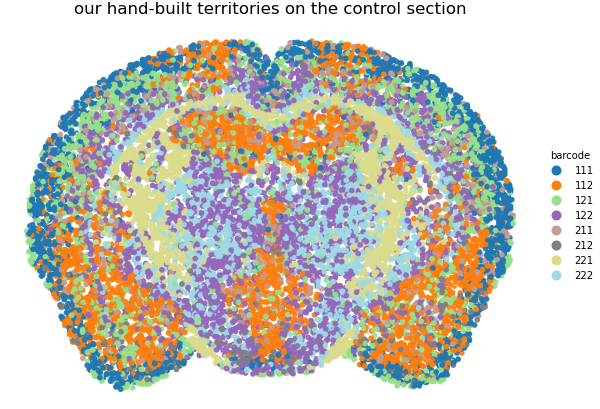

In [11]:
# paint the demo pixels by their hand-made barcode
demo_obs = control.obs.iloc[demo_idx].copy()
demo_obs["barcode"] = [barcodes[i] for i in range(len(demo_idx))]

uniq = sorted(demo_obs["barcode"].unique())
palette = plt.cm.tab20(np.linspace(0, 1, len(uniq)))
cmap = {b: palette[i] for i, b in enumerate(uniq)}

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.scatter(demo_obs["zccf"], -demo_obs["yccf"],
           c=[cmap[b] for b in demo_obs["barcode"]], s=6, alpha=0.9, rasterized=True)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title("our hand-built territories on the control section", fontsize=FS["m"])
# a compact legend of barcodes
handles = [plt.Line2D([0], [0], marker="o", ls="", mfc=cmap[b], mec="none", label=b) for b in uniq]
ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.0, 0.5),
          fontsize=FS["xs"], title="barcode", title_fontsize=FS["xs"])
plt.tight_layout(); plt.show()

⚠️ **CHECKPOINT.** The territories are spatially coherent: each barcode lands in a connected
region of the section, recognisably tracing cortex, white-matter tracts, and deep structures. A
clustering driven by noise would have scattered colours uniformly. Ours did not, because the
differential-lipid gate refused every cut that was not backed by real lipid differences.

This is the full atlas algorithm in miniature. The real EUCLID adds the backSPIN bipartition, the
XGBoost smoother-and-gate, the continuity check, and runs to depth 11 across the whole-brain stack to
produce 539 lipizones. The helper `cl.embedding` exposes the production embedding pieces (`seeded_nmf`,
`harmonize`, `leiden_clusters`, `knn_transfer`) so you never have to re-type them. But you have now
*built* the principle, and that is what lets you trust the colours when somebody hands them to you.

# Part 2: the same test, turned on pregnancy

We built a statistical gate to decide whether two groups of pixels differ in their lipids. We used it
*inside* a clustering, to validate splits. Now we point the exact same machine at the real biological
question: take a fixed territory, and ask whether **control** and **pregnant** pixels inside it differ.
Nothing new to learn. Same Mann-Whitney, same Benjamini-Hochberg, same log2 fold change. Different job.

The tested version of our gate lives in the helper as `cl.analysis.differential_lipids`. It does
exactly what `differential_count` does, lipid by lipid, but returns the full tidy table sorted by fold
change, with both groups' means, the raw p, the BH q-value, and the significance flag. We use it from
here on so we can spend our attention on the biology.

## one thing to get right: which data, and which direction

Two rules the atlas is strict about, and so are we.

**Use the uMAIA-normalized data, not the batch-corrected embedding.** Clustering wants pixels from
different brains pushed together so territories line up; that is what Harmony and the NMF embedding are
for. But a *differential test* must compare the actual measured intensities, because a batch
correction can quietly erase or invent a condition difference. So the test runs on `adata.X`, the
uMAIA values, exactly as loaded.

**Fix the direction once.** We compute every fold change as `log2(mean_pregnant / mean_control)`. A
positive log2FC means the lipid is *higher in pregnancy*; negative means lower. We will hold that
convention through every plot.

🔬 **TASK.** Run the overall control-vs-pregnant test across all pixels and all 173 lipids.

In [12]:
# the course's case-control test: Wilcoxon rank-sum + Benjamini-Hochberg, on uMAIA data.
# group1 = control (naive), group2 = pregnant -> log2FC is pregnant / control.
# NOTE: one name below, "HexCer 36:1:O2" (colon before O2, not the usual ";O2"), is flagged
# upstream as a corrupted lipid and dropped by hand in the atlas pregnancy analysis. We keep it
# visible here so you see the raw table, but read its big fall as an artifact, not biology.
diff = analysis.differential_lipids(adata, group_col="Condition",
                                    group1="naive", group2="pregnant",
                                    min_fc=0.2, pthr=0.05)
print("lipids tested:", len(diff), " | significant:", int(diff["sig"].sum()))
diff_sig = diff[diff["sig"]].sort_values("log2fc", ascending=False)
print("\nsignificant lipids, highest to lowest fold change:")
print(diff_sig[["lipid", "log2fc", "qval"]].to_string(index=False))

lipids tested: 173  | significant: 13

significant lipids, highest to lowest fold change:
         lipid    log2fc          qval
HexCer 41:1;O2  0.699835  0.000000e+00
HexCer 40:2;O2  0.580870  0.000000e+00
       PA 34:1  0.456308  0.000000e+00
   Cer 40:2;O2  0.344016  0.000000e+00
HexCer 42:2;O2  0.304476 9.156591e-302
HexCer 40:1;O2  0.299635  0.000000e+00
      LPE 22:6  0.295409  0.000000e+00
    SM 34:1;O2  0.288712  0.000000e+00
   Cer 42:2;O2  0.265017  0.000000e+00
       PE 40:6  0.238173  0.000000e+00
       PC 40:1 -0.216018  0.000000e+00
       PC 42:1 -0.256399  0.000000e+00
HexCer 36:1:O2 -0.468416  0.000000e+00


⚠️ **CHECKPOINT.** Thirteen lipids pass both thresholds. Read the up-going list carefully, because the
prose has to match the printed table. Seven of the ten lipids rising in pregnancy are sphingolipids:
**HexCer 41:1;O2, HexCer 40:2;O2, Cer 40:2;O2, HexCer 42:2;O2, HexCer 40:1;O2, SM 34:1;O2, Cer
42:2;O2**, the hexosylceramides, ceramides, and sphingomyelins, the building blocks of myelin. So the
up plume is *dominated* by sphingolipids, not made only of them. The other three risers are
glycerophospholipids and are not sphingolipids: **PA 34:1** (the third-largest fold change of all, and
in fact the second co-headline pregnancy lipid that the atlas tracks spatially alongside the myelin
marker), **LPE 22:6**, and **PE 40:6**. **HexCer 42:2;O2** in particular is the myelin marker the paper
highlights.

Now the down side, and there are *three* lipids going down, not just phosphatidylcholines. Two are
long-chain PCs (**PC 40:1** and **PC 42:1**), but the single largest-magnitude down lipid is **HexCer
36:1:O2** at log2FC -0.468, a bigger move than either PC. One warning attaches to that last name. Look
closely: it is written `HexCer 36:1:O2` with a *colon* before the O2, not the usual semicolon `;O2`.
That malformed name is exactly the lipid the upstream pregnancy analysis (notebook 009b) drops by hand
as a corrupted measurement, so its apparently strong fall here is most likely a measurement artifact,
not biology, and you should not read it as a real pregnancy effect. It matters here for a second
reason: its name starts with `HexCer`, so it silently rides into the sphingolipid myelination score we
build at the end of the notebook. Keep that caveat in your pocket when you read that map. Setting the
artifact aside, the overall signal of pregnancy at this coronal plane is **sphingolipids up**,
consistent with widespread adaptive myelination.

We will make that statement visual and then quantitative.

## the volcano: significance against effect size

A volcano plot is the standard one-glance summary of a differential test. Each dot is a lipid. The
x-axis is the log2 fold change (left = down in pregnancy, right = up). The y-axis is `-log10(q)`, so
the *more significant* a lipid, the *higher* it sits. The dashed lines mark our two thresholds. The
lipids that clear both, far from centre and high up, are the discoveries; they are coloured.

The shape is why it is called a volcano: a wide, flat base of unchanged lipids near `log2FC = 0`, and
two plumes erupting up the sides where real, large changes live.

🔬 **TASK.** Draw the volcano with `cl.plotting.volcano`, labelling the top hits.

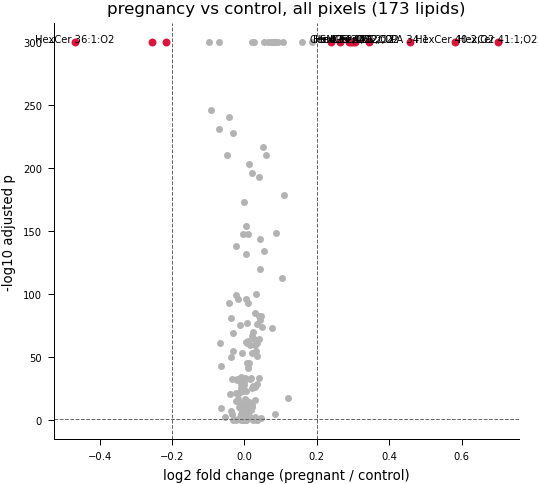

In [13]:
ax = plotting.volcano(diff, fc_col="log2fc", q_col="qval",
                      fc_thresh=0.2, q_thresh=0.05, label_col="lipid", top_n=10,
                      title="pregnancy vs control, all pixels (173 lipids)")
plt.show()

⚠️ **CHECKPOINT.** The crimson dots on the **right** plume are the sphingolipids rising in
pregnancy; their labels read `HexCer`, `Cer`, `SM`. The grey cloud at the bottom centre is the majority
of lipids that did not change. The dashed horizontal line is `q = 0.05`; the dashed vertical lines are
`log2FC = ±0.2`. A lipid is coloured only if it is past *both*.

❓ **QUESTION.** Some dots sit very high (tiny q) but close to the centre (small fold change), so they
stay grey. Why is that the right call? (With 174768 pixels even a trivial difference is "real". The
fold-change threshold is what keeps us reporting changes that matter biologically, not just changes we
can detect.)

## is the change everywhere, or somewhere? the per-region test

"Sphingolipids up overall" is an average over the whole section, and an average can hide where the
action is. Pregnancy might remodel the cortex while leaving the thalamus untouched, and the overall
test would blur the two. So we repeat the test **inside each Allen region**: same control-vs-pregnant
comparison, but restricted to pixels that share an anatomical `acronym`. This localises the biology.

🔬 **TASK.** Run the differential test region by region, keeping regions with enough pixels in both
conditions, and tally how many lipids change in each.

In [14]:
# regions present in BOTH conditions with a decent pixel count
counts = adata.obs.groupby(["acronym", "Condition"], observed=True).size().unstack(fill_value=0)
usable = counts[(counts.get("naive", 0) >= 200) & (counts.get("pregnant", 0) >= 200)].index.tolist()
print(f"{len(usable)} Allen regions have >=200 pixels in both control and pregnant")

region_rows = []
region_tables = {}
for reg in usable:
    sub = adata[adata.obs["acronym"] == reg]
    d = analysis.differential_lipids(sub, "Condition", "naive", "pregnant",
                                     min_fc=0.2, pthr=0.05)
    region_tables[reg] = d
    region_rows.append((reg, int(d["sig"].sum()),
                        int(((d["log2fc"] > 0.2) & (d["qval"] < 0.05)).sum()),
                        int(((d["log2fc"] < -0.2) & (d["qval"] < 0.05)).sum())))

region_diff = pd.DataFrame(region_rows, columns=["acronym", "n_sig", "n_up", "n_down"]) \
                .sort_values("n_sig", ascending=False).reset_index(drop=True)
print("\nmost-remodeled regions (lipids changed in pregnancy):")
print(region_diff.head(12).to_string(index=False))

85 Allen regions have >=200 pixels in both control and pregnant



most-remodeled regions (lipids changed in pregnancy):
     acronym  n_sig  n_up  n_down
         opt    152    86      66
         alv    142    69      73
    SSp-ul6a    129    73      56
    SSp-ll6a    119    69      50
        chpl    117     6     111
       RSPv5    116     6     110
    SSp-un6a    114    67      47
fiber tracts    114    62      52
          CL     98    53      45
         ARH     97    17      80
          RT     96    41      55
         VPL     94    49      45


⚠️ **CHECKPOINT.** The regions are ranked by how many lipids changed. The change is *not*
uniform: a handful of regions carry most of the remodeling, while many barely move. Read the `n_up` and
`n_down` columns and you see the remodeling has a *direction* that depends on the region. The
somatosensory and visceral cortical layers (the `SSp-` and `VISC` rows) are dominated by rises, the
same up direction as the overall result. A few regions go the other way: the choroid plexus (`chpl`)
and retrosplenial cortex (`RSPv`) are dominated by *falls*. Pregnancy is not a single lift of the whole
brain; it rebuilds some territories and trims others.

🔬 **TASK.** Make this a picture: a bar chart of the most-remodeled regions, split into lipids up
(crimson) and down (steel) in pregnancy.

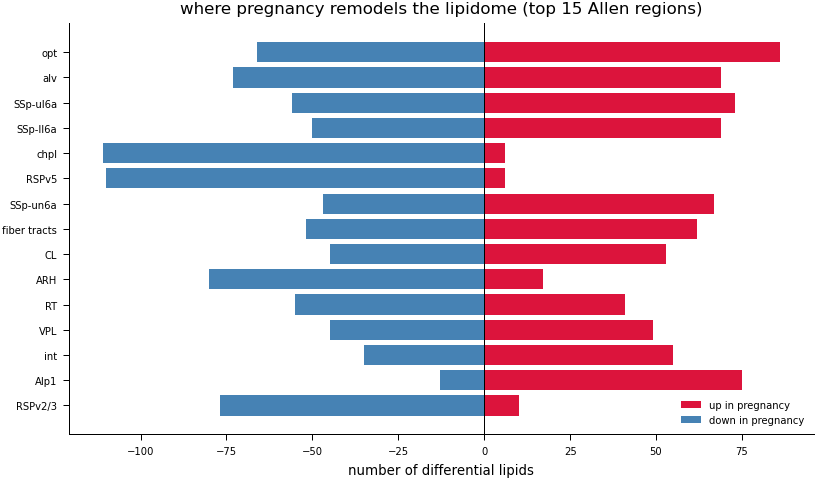

In [15]:
top = region_diff.head(15)
fig, ax = plt.subplots(figsize=(7, 4.2))
y = np.arange(len(top))
ax.barh(y, top["n_up"], color="crimson", label="up in pregnancy")
ax.barh(y, -top["n_down"], color="steelblue", label="down in pregnancy")
ax.set_yticks(y); ax.set_yticklabels(top["acronym"], fontsize=FS["xs"])
ax.invert_yaxis()
ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel("number of differential lipids")
ax.set_title("where pregnancy remodels the lipidome (top 15 Allen regions)", fontsize=FS["m"])
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

❓ **QUESTION.** Why test per region at all, instead of trusting the overall volcano? Because the
overall test answers "does the average pixel change?", while the per-region test answers "*where* does
the brain change?". The second question is the biological one. The atlas makes exactly this move when
it reports that the outer cortex is vastly remodeled while other regions are spared.

# Part 3: read the territories through their marker lipids

We have a test and we have territories. Now we interpret. A territory means little until you can say
*what it is made of*. The way to do that is the same one-vs-rest logic as a marker gene in single-cell:
for each territory, find the lipids that are higher *inside* it than in the rest of the brain. Those are
its **marker lipids**, its molecular fingerprint.

We do this on the **control** brain, using the pre-computed `subclass_name` annotation (31 lipid
subclasses of territory) so the markers are interpretable and stable. The recipe is one-vs-rest: for
each group, log2( mean inside / mean outside ) per lipid, then take the top few. The helper
`cl.analysis.marker_lipids` does exactly this.

🔬 **TASK.** Find the top marker lipids of each control subclass.

In [16]:
# one-vs-rest marker lipids per subclass, on the control brain
ctrl_sub = control[control.obs["subclass_name"].notna()].copy()
markers = analysis.marker_lipids(ctrl_sub, group_key="subclass_name", top_n=4)

print(f"{len(markers)} subclasses, with their top-4 marker lipids (log2 fold inside vs outside):\n")
for name in list(markers)[:8]:
    pretty = ", ".join(f"{lip} ({fc:+.2f})" for lip, fc in markers[name])
    print(f"  {name:<34s}: {pretty}")

31 subclasses, with their top-4 marker lipids (log2 fold inside vs outside):

  Cortical layers 1 and 2-3         : PS 42:9 (+1.08), PG 36:1 (+0.85), SM 31:1;O2 (+0.83), PE O-40:7 (+0.82)
  Cortical layer 4                  : PE 42:9 (+0.63), PC 38:6 (+0.61), PG 36:1 (+0.59), PG 40:6 (+0.57)
  Pallidum and projections          : PI 40:7 (+0.63), PE O-40:7 (+0.60), PG 36:1 (+0.59), PC 32:0 (+0.52)
  Cortical layers 2-3 and 4         : PG 36:1 (+0.70), PE O-40:7 (+0.69), PE 42:9 (+0.64), PA 38:5 (+0.59)
  Piriform cortex                   : SM 31:1;O2 (+0.75), PA 38:5 (+0.68), PS 42:9 (+0.68), PC 32:0 (+0.63)
  Mid/hindbrain white matter        : HexCer 36:1:O2 (+1.14), SM 42:3;O2 (+1.09), Cer 40:0;O2 (+1.08), HexCer 36:1;O2 (+1.04)
  Striatum, hypothalamus and hippocampus: PI 36:3 (+0.61), SM 36:2;O2 (+0.55), PI 40:7 (+0.45), PC 38:5 (+0.44)
  Subcortical plate, hippocampus and hypothalamus: SM 36:2;O2 (+0.71), PC 38:5 (+0.58), PA 38:5 (+0.55), PC 32:0 (+0.53)


⚠️ **CHECKPOINT.** Each subclass comes back with a short list of lipids that are strongly
enriched inside it. The fold changes are large and positive, which is what a real marker looks like.
You can already read biology off the names: subclasses tied to white matter surface sphingolipids
(`HexCer`, `SM`, `Cer`), while grey-matter subclasses surface glycerophospholipids (`PC`, `PE`, `PS`).
The lipids that *define* a territory and the lipids that *change* in pregnancy turn out to overlap, the
sphingolipids, which is the first hint that pregnancy is acting on the myelin compartment.

## the sorted heatmaps: the whole fingerprint at once

A marker list is a peek. The full picture is a heatmap: rows are territories, columns are lipids, each
cell is the average (0-to-1 normalized) intensity of that lipid in that territory. But a raw heatmap is
unreadable, because the rows and columns arrive in arbitrary order. The trick that makes it *beautiful*
is **optimal-leaf ordering on cosine distance**: cluster the rows so similar territories sit next to
each other, do the same for the columns so co-varying lipids sit together, and the structure snaps into
diagonal blocks you can read at a glance. This sorting is an art, so we use the atlas's exact recipe
through `cl.plotting.sorted_lipid_heatmap`; it does the per-lipid 0-1 scaling, the group averaging, and
the cosine optimal-leaf ordering on both axes for us.

We draw it twice: once with rows = **Allen anatomy** (`acronym`), once with rows = **lipid subclass**
(`subclass_name`). Same lipids on the x-axis, two different ways to slice the rows.

🔬 **TASK.** Draw the anatomy-by-lipid heatmap of the control brain.

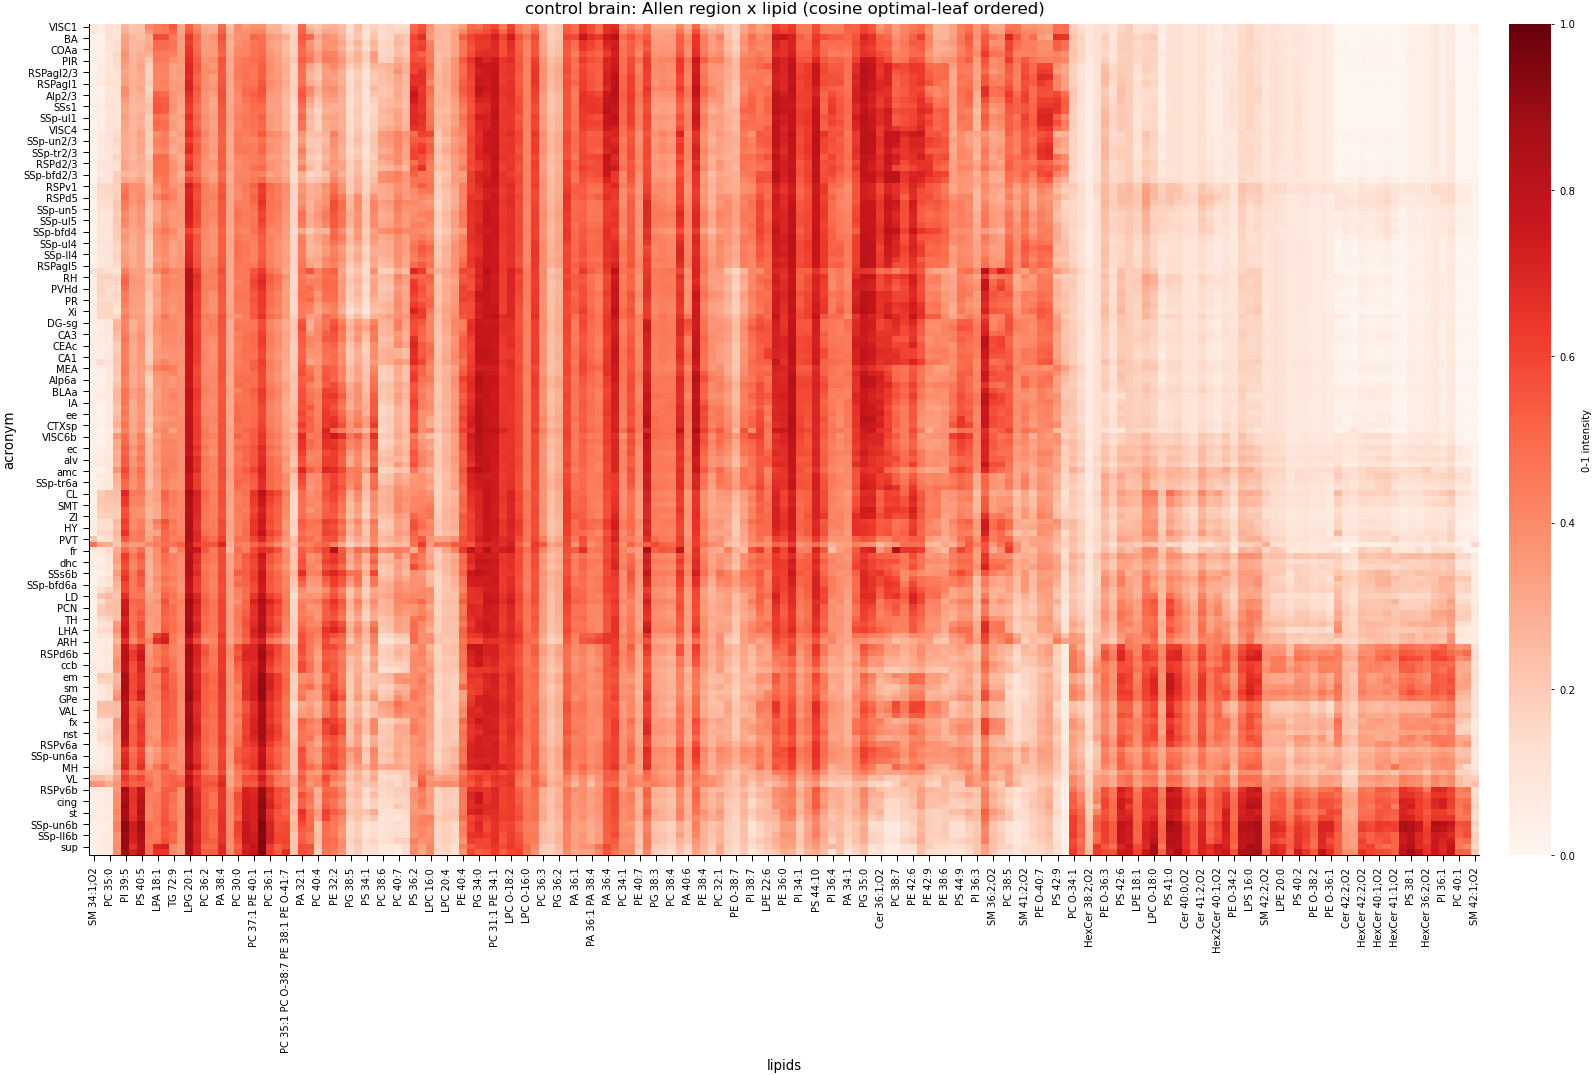

heatmap shape (regions x lipids): (146, 173)


In [17]:
# anatomy x lipid: each row an Allen region, columns the 173 lipids, cosine-sorted both ways
ax, sorted_anat = plotting.sorted_lipid_heatmap(
    control, group_key="acronym", cmap="Reds", figsize=(16, 9),
    title="control brain: Allen region x lipid (cosine optimal-leaf ordered)")
plt.show()
print("heatmap shape (regions x lipids):", sorted_anat.shape)

⚠️ **CHECKPOINT.** The sorting reveals blocks. Reading the diagonal, groups of regions share a
group of high lipids: that is the lipidomic signature of an anatomical system. The clearest block is
the white-matter-like regions lighting up on the sphingolipid columns at one end of the lipid axis,
opposite the grey-matter regions lighting up on the glycerophospholipid columns. The columns are sorted
so chemically related lipids cluster, which is why the bright patches are contiguous and not scattered.

🔬 **TASK.** Now the lipid-subclass version: rows are the 31 lipizone subclasses instead of anatomy.

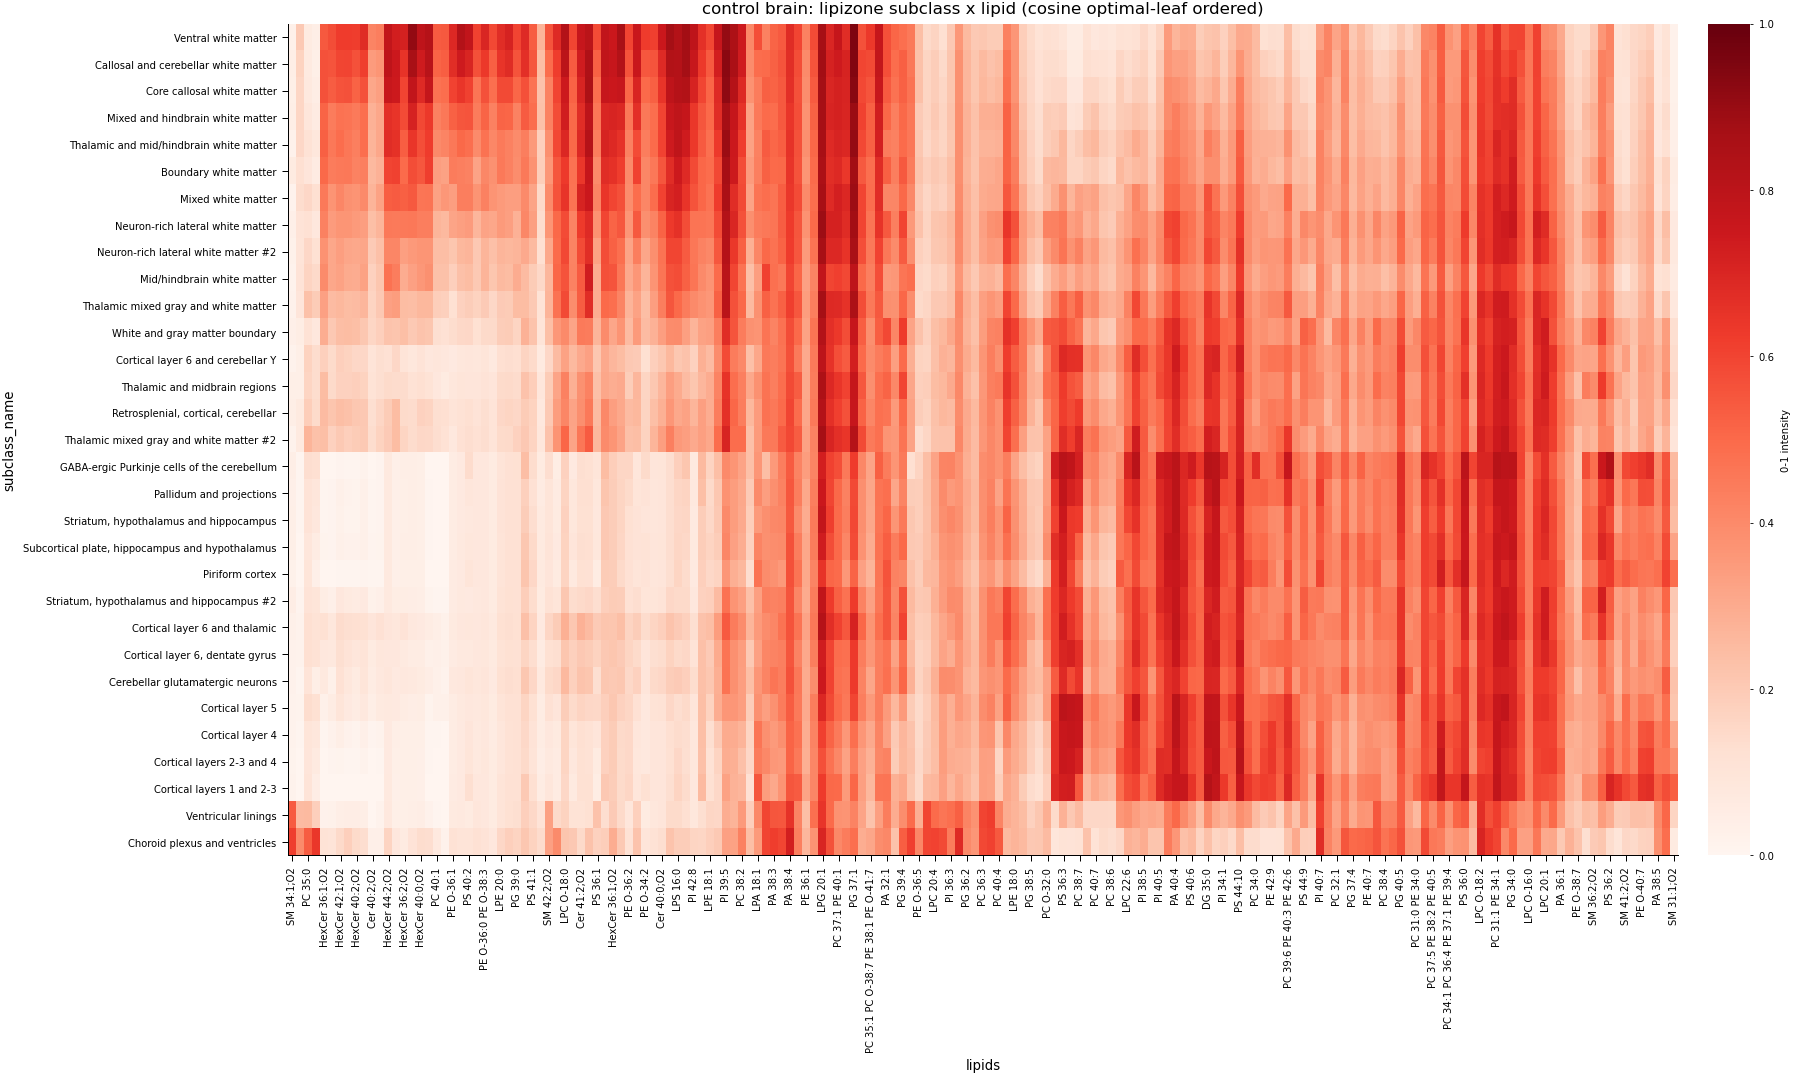

heatmap shape (subclasses x lipids): (31, 173)


In [18]:
# subclass x lipid: rows are the lipid-defined territory subclasses
ax, sorted_sub = plotting.sorted_lipid_heatmap(
    control, group_key="subclass_name", cmap="Reds", figsize=(16, 9),
    title="control brain: lipizone subclass x lipid (cosine optimal-leaf ordered)")
plt.show()
print("heatmap shape (subclasses x lipids):", sorted_sub.shape)

❓ **QUESTION.** The anatomy heatmap and the subclass heatmap show the same lipids but cluster
rows by two different definitions of "territory", one anatomical and one purely lipid-driven. They
look broadly congruent. What does that congruence tell you? (That the lipid-defined territories largely
*respect* anatomy: the brain's chemistry and its atlas geography are two readings of the same
organization. Where they disagree is where lipids see structure the atlas does not, which is the whole
reason lipizones exist.)

# Part 4: composite scores, painted back onto the brain

Single lipids are noisy and there are 173 of them. Often the cleaner readout is a **composite score**: a
single number per pixel that sums up many related lipids, which we can then paint across the tissue and
read like a map. We build two, each answering a different question, and we put both back on the brain.

## the membrane-remodeling score: net synthesis or net turnover

The atlas summarises pregnancy's effect on a territory with one number: the **sum of all the lipid
log2 fold changes** in that territory. The intuition is a balance sheet. If most lipids went up, the
sum is positive, and the territory is in net *biosynthesis*, building membrane. If most went down, the
sum is negative, net *turnover*, breaking membrane down. A territory near zero is in balance. The
helper `cl.analysis.membrane_remodeling_score` takes the per-region differential tables we already
computed and returns this sum per region.

🔬 **TASK.** Compute the membrane-remodeling score for every usable region and rank them.

In [19]:
# membrane remodeling per region = sum of that region's lipid log2 fold changes
membrane = analysis.membrane_remodeling_score(region_tables)
membrane = pd.Series(membrane).sort_values()

print("most net-turnover regions (negative sum of log2FC):")
print(membrane.head(6).round(2).to_string())
print("\nmost net-biosynthesis regions (positive sum of log2FC):")
print(membrane.tail(6).round(2).to_string())

most net-turnover regions (negative sum of log2FC):
chpl      -80.89
ARH       -44.33
RSPv5     -44.25
VMH       -34.91
PVi       -24.48
RSPv2/3   -22.77

most net-biosynthesis regions (positive sum of log2FC):
SSp-un2/3    27.43
SSs6a        27.44
VISC6a       29.39
VISC5        29.56
alv          30.20
CA3          41.06


Now paint that score onto the tissue. We map each pixel to its region's membrane score and
scatter it on the pregnant section in CCF coordinates, with a divergent colormap centred at zero: blue
for net turnover, red for net biosynthesis.

🔬 **TASK.** Run the spatial map of the membrane-remodeling score.

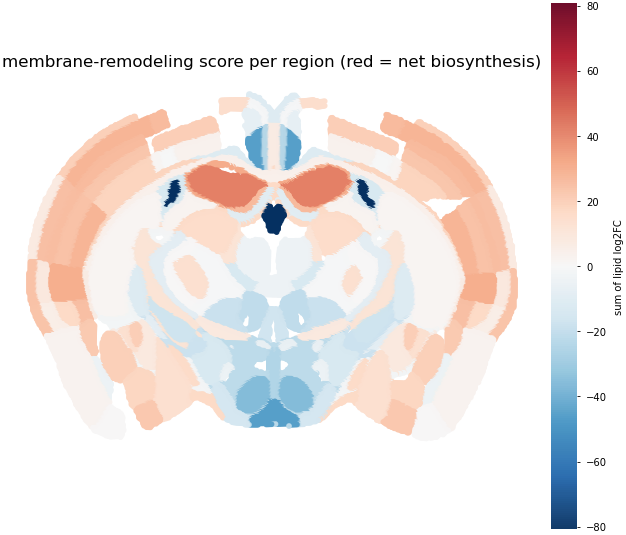

In [20]:
# attach each region's membrane score to its pixels, on the pregnant section
preg = adata[adata.obs["Condition"] == "pregnant"].copy()
preg.obs["membrane"] = preg.obs["acronym"].map(membrane).astype(float)
shown = preg[preg.obs["membrane"].notna()]

vmax = np.nanmax(np.abs(shown.obs["membrane"]))
fig, ax = plt.subplots(figsize=(5.4, 5.4))
sc = ax.scatter(shown.obs["zccf"], -shown.obs["yccf"], c=shown.obs["membrane"],
                cmap="RdBu_r", vmin=-vmax, vmax=vmax, s=6, alpha=0.95, rasterized=True)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title("membrane-remodeling score per region (red = net biosynthesis)", fontsize=FS["m"])
cl.style.lightweight_colorbar(sc, ax, label="sum of lipid log2FC")
plt.tight_layout(); plt.show()

⚠️ **CHECKPOINT.** The map is not uniform. Some regions glow red (net building of membrane in
pregnancy) and others blue (net turnover), and the pattern respects anatomy because the score is
computed per region. This is the atlas's "region-specific remodeling" result made visible on a single
plane: pregnancy does not lift or lower the whole brain, it rebuilds specific territories.

## the myelination score: where the sphingolipids live

The second score is simpler and ties the whole notebook together. The differential test told us
sphingolipids rise in pregnancy. So we build a **myelination score**: for each pixel, the mean
z-scored intensity of all its sphingolipids (the `HexCer`, `Cer`, and `SM` lipids). High score = a
sphingolipid-rich, myelin-rich pixel. The helper `cl.analysis.myelination_score` does exactly this
z-score-and-average over the sphingolipid columns.

We compute it for every pixel and paint control and pregnant side by side, so any pregnancy-driven rise
in the sphingolipid compartment is visible as a brightening.

🔬 **TASK.** Compute the myelination score and map it on both sections.

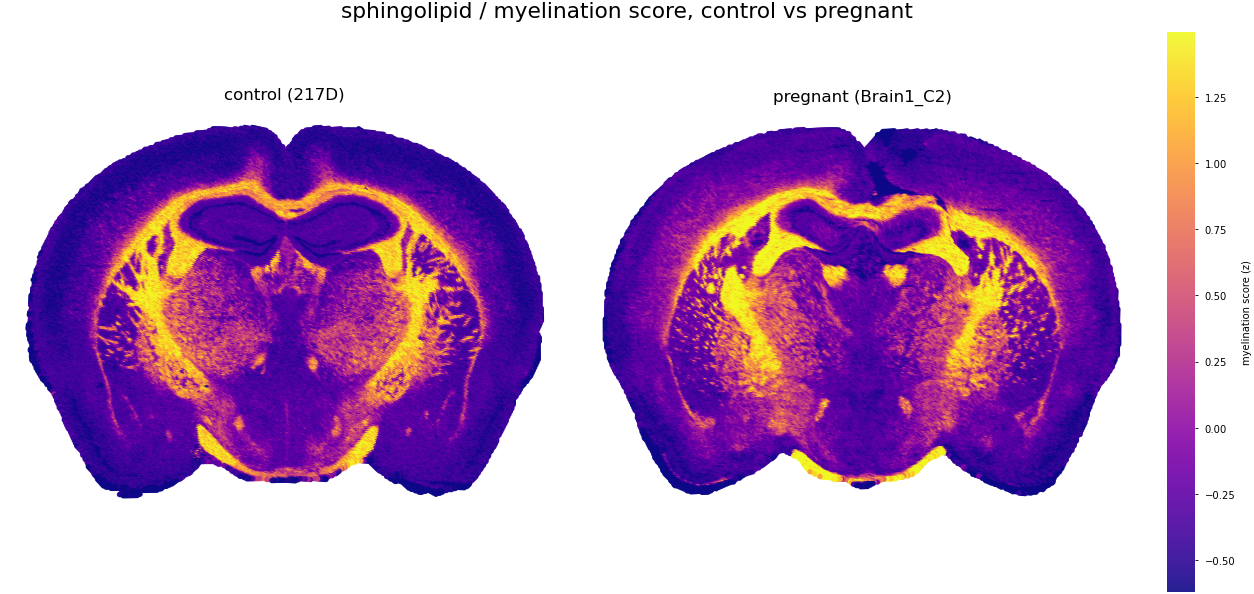

In [21]:
# mean z-scored sphingolipid (HexCer/Cer/SM) intensity per pixel
adata.obs["myelination"] = analysis.myelination_score(adata)

# shared colour scale across both sections so the comparison is fair
vmin, vmax = np.quantile(adata.obs["myelination"], [0.02, 0.98])
fig, axes = plt.subplots(1, 2, figsize=(10.5, 5.0), constrained_layout=True)
for ax, cond, title in zip(axes, ["naive", "pregnant"], ["control (217D)", "pregnant (Brain1_C2)"]):
    s = adata[adata.obs["Condition"] == cond]
    sc = ax.scatter(s.obs["zccf"], -s.obs["yccf"], c=s.obs["myelination"],
                    cmap="plasma", vmin=vmin, vmax=vmax, s=5, alpha=0.9, rasterized=True)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_title(title, fontsize=FS["m"])
cl.style.lightweight_colorbar(sc, list(axes), label="myelination score (z)")
plt.suptitle("sphingolipid / myelination score, control vs pregnant", fontsize=FS["l"])
plt.show()

⚠️ **CHECKPOINT.** In both sections the bright (high-score) pixels trace the white-matter
tracts, exactly where myelin lives, which validates the score: it is finding real anatomy, not noise.
Compare the two panels in the white-matter and its borders; the pregnant section reads brighter in the
sphingolipid compartment, the spatial echo of the volcano's right plume.

🔬 **TASK.** Put a number on the eye's impression: the mean myelination score in each condition, and
its difference.

In [22]:
m_ctrl = adata.obs.loc[adata.obs["Condition"] == "naive", "myelination"].mean()
m_preg = adata.obs.loc[adata.obs["Condition"] == "pregnant", "myelination"].mean()
print(f"mean myelination score  control: {m_ctrl:+.3f}")
print(f"mean myelination score  pregnant: {m_preg:+.3f}")
print(f"difference (pregnant - control): {m_preg - m_ctrl:+.3f}")

mean myelination score  control: -0.043
mean myelination score  pregnant: +0.040
difference (pregnant - control): +0.083


❓ **QUESTION.** The difference is small in absolute z-units, and there is a structural reason not to
over-read it. The myelination score is z-scored over *all* pixels of both conditions pooled together,
so by construction the control and pregnant means are coupled and forced to sit on opposite sides of
zero and nearly cancel; the +0.083 gap is really just saying pregnant pixels sit a little above the
shared mean and control pixels a little below, not that the score has some absolute magnitude. What
carries the weight is not that number but that it points the same way as every other result in this
notebook: the volcano (sphingolipids up), the markers (sphingolipids define white matter), the
per-region bars (rises dominate the remodeled regions). When four independent readouts all point the
same way, the conclusion is robust. That convergence, not any single p-value or z-gap, is what makes
the biology believable.

# what we did, and why it holds together

We built a clustering algorithm from scratch and used it to discover the one rule that makes clustering
mean something: a split is only real if the two halves differ in measurable lipids. We built that
differential test, the Mann-Whitney rank-sum with a Benjamini-Hochberg correction, brick by brick,
from ranks to fold change to false-discovery control. Then we turned the same test on pregnancy.

The biology came out clean and consistent. **Sphingolipids rise in the pregnant brain.** We saw it four
ways:

- the **overall volcano**: HexCer, Cer, and SM lipids dominate the up plume, with the myelin marker
  HexCer 42:2;O2 among them,
- the **per-region test**: the remodeling is concentrated, not uniform, with rises outnumbering falls
  in the most-changed regions,
- the **marker lipids and heatmaps**: the lipids that define white matter are the same sphingolipids
  that change, tying the change to the myelin compartment,
- the **composite scores**: the membrane-remodeling map shows region-specific rebuilding, and the
  myelination score is higher in pregnancy and traces the white-matter tracts in both brains.

Each result is a different lens on the same fact, which is why we believe it. The headline reading,
following the atlas, is **adaptive myelination in pregnancy**: the maternal brain rebuilds its
sphingolipid-rich, myelin-rich compartment.

A caveat worth stating plainly, because honesty is the whole point of building the test yourself. We
compared *one* control section to *one* pregnant section, a single coronal plane. That is enough to
*see* the effect and to learn the method, but a real claim needs replicates across animals and planes,
which is exactly what the full atlas provides. The tools you built here, the gate and the score, are
the same ones that scale to that full design.

Next door (notebook 8) we ask *why*: which genes, read out from MERFISH, predict these lipid changes,
linking the lipidome you just dissected back to the transcriptome.